Starting optimization...
Step   0 | Total: 2.0855 | Det: 0.7161 | W-NPS: 0.1123 | W-TV: 0.5316 | W-Style: 0.7255
Step   1 | Total: 1.8770 | Det: 0.4045 | W-NPS: 0.1118 | W-TV: 0.5801 | W-Style: 0.7806
Step   2 | Total: 2.0892 | Det: 0.5829 | W-NPS: 0.1122 | W-TV: 0.6071 | W-Style: 0.7869
Step   3 | Total: 1.6154 | Det: 0.0949 | W-NPS: 0.1123 | W-TV: 0.6207 | W-Style: 0.7875
Step   4 | Total: 1.8811 | Det: 0.3573 | W-NPS: 0.1121 | W-TV: 0.6276 | W-Style: 0.7841
Step   5 | Total: 2.1051 | Det: 0.5775 | W-NPS: 0.1119 | W-TV: 0.6328 | W-Style: 0.7829
Step   6 | Total: 1.8479 | Det: 0.3159 | W-NPS: 0.1117 | W-TV: 0.6373 | W-Style: 0.7829
Step   7 | Total: 1.6411 | Det: 0.1031 | W-NPS: 0.1115 | W-TV: 0.6427 | W-Style: 0.7839
Step   8 | Total: 1.9599 | Det: 0.4185 | W-NPS: 0.1113 | W-TV: 0.6468 | W-Style: 0.7833
Step   9 | Total: 2.0372 | Det: 0.4931 | W-NPS: 0.1109 | W-TV: 0.6502 | W-Style: 0.7830
Step  10 | Total: 1.7269 | Det: 0.1788 | W-NPS: 0.1106 | W-TV: 0.6544 | W-Style: 0.7830
Step  1

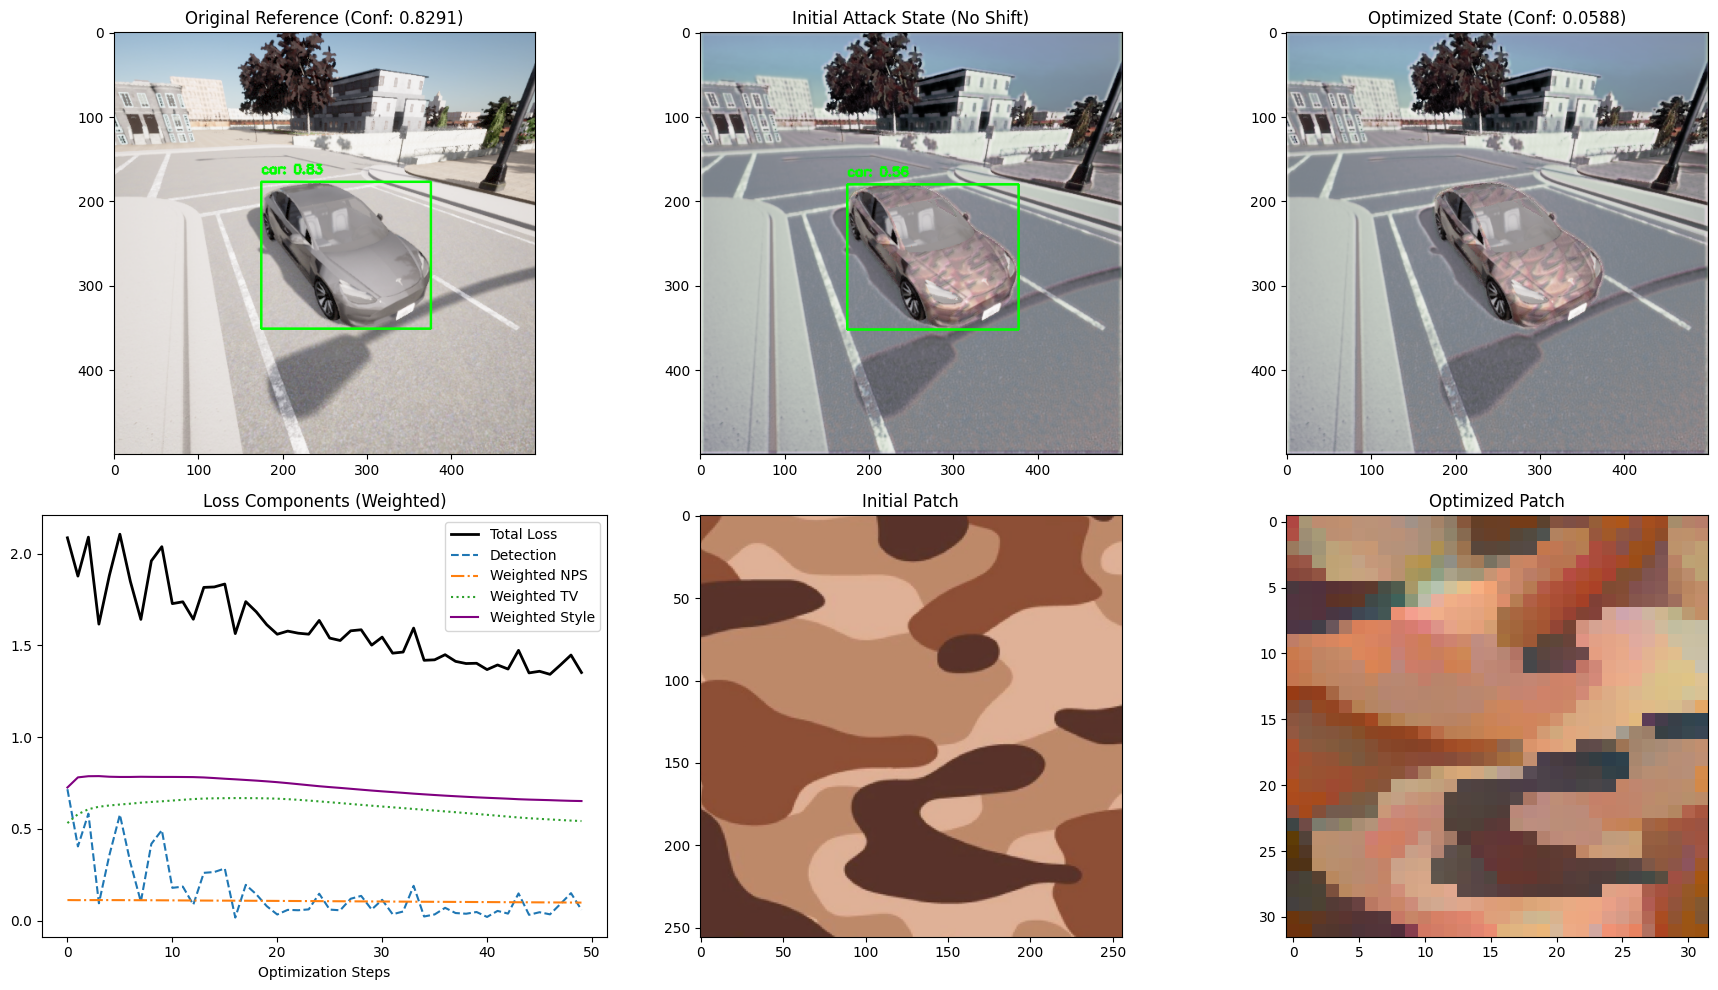

In [ ]:
import tensorflow as tf
import numpy as np
import os
import cv2
from glob import glob
import matplotlib.pyplot as plt
import pandas as pd


# ========== CONFIGURATION ==========

DATASET_FOLDER    = 'sample_dataset'
METADATA_CSV      = os.path.join(DATASET_FOLDER, 'metadata.csv')
SAMPLE_IDX        = 2468

MODEL_PATH_RENDERER = 'models/k3_100epch_wo_custom_loss_model.h5'
MODEL_PATH_YOLO     = 'yolov8n_saved_model'

IMG_SIZE          = (500, 500)
YOLO_SIZE         = (640, 640)
TRAINING_STEPS    = 50

TEX_RES           = 32
TEX_UPSCALE_RES   = 256

INITIAL_TEX_PATH  = 'textures/camo_muddy.png'
STYLE_IMAGE_PATH  = 'textures/camo_muddy.png'

ATTACK_MODE       = 'hide'   # 'hide' or 'misclassification'

DETECTION_WEIGHT  = 1.0
TV_WEIGHT         = 5.0
NPS_WEIGHT        = 1.0
STYLE_WEIGHT      = 0.1
LEARNING_RATE     = 0.01
NPS_DIM           = 5

VEHICLE_CLASS_IDS = [2, 7, 5]  # car, truck, bus

CLASSES = {
    0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus',
    6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant',
    11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat',
    16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear',
    22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag',
    27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard',
    32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove',
    36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle',
    40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl',
    46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli',
    51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake',
    56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table',
    61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard',
    67: 'cell phone', 68: 'microwave', 69: 'oven', 70: 'toaster', 71: 'sink',
    72: 'refrigerator', 73: 'book', 74: 'clock', 75: 'vase', 76: 'scissors',
    77: 'teddy bear', 78: 'hair drier', 79: 'toothbrush'
}


# ========== SETUP (models, NPS palette, style target, texture variable) ========== 

# load models
renderer_model = tf.keras.models.load_model(MODEL_PATH_RENDERER, compile=False)

yolo_loaded = tf.saved_model.load(MODEL_PATH_YOLO)
yolo_infer  = yolo_loaded.signatures['serving_default']

vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
vgg.trainable = False
style_layers    = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']
style_extractor = tf.keras.Model([vgg.input], [vgg.get_layer(n).output for n in style_layers])

# printable colour palette for NPS
grid_1d = tf.linspace(0.05, 0.95, NPS_DIM)
r, g, b = tf.meshgrid(grid_1d, grid_1d, grid_1d)
_colors = tf.reshape(tf.stack([r, g, b], axis=-1), [-1, 3])
PRINTABLE_COLORS = tf.boolean_mask(_colors, (tf.reduce_max(_colors, axis=1) - tf.reduce_min(_colors, axis=1)) < 0.9)

# style target gram matrices
def gram_matrix(x):
    return tf.linalg.einsum('bijc,bijd->bcd', x, x) / tf.cast(tf.shape(x)[1] * tf.shape(x)[2], tf.float32)

def load_image_for_style(path):
    img = tf.image.convert_image_dtype(tf.image.decode_png(tf.io.read_file(path), channels=3), tf.float32)
    return tf.expand_dims(tf.image.resize(img, [TEX_UPSCALE_RES, TEX_UPSCALE_RES]), 0)

target_style_img = load_image_for_style(STYLE_IMAGE_PATH)
TARGET_GRAMS = [gram_matrix(f) for f in style_extractor(tf.keras.applications.vgg19.preprocess_input(target_style_img * 255.0))]

# texture variable
initial_tex = load_image_for_style(INITIAL_TEX_PATH)
tf_texture  = tf.Variable(tf.image.resize(initial_tex, [TEX_RES, TEX_RES])[0], dtype=tf.float32)

df_meta   = pd.read_csv(METADATA_CSV)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)


# ========== DATASET ==========

def load_dataset_sample(idx):
    row = df_meta.iloc[idx]
    base_name = str(row['filename']).zfill(5)

    def load_img(subfolder, ext):
        path = os.path.join(DATASET_FOLDER, subfolder, f"{base_name}{ext}")
        if not os.path.exists(path):
            path = glob(os.path.join(DATASET_FOLDER, subfolder, f"{base_name}.*"))[0]
        img = tf.image.decode_image(tf.io.read_file(path), channels=3)
        return tf.image.resize(tf.image.convert_image_dtype(img, tf.float32), IMG_SIZE)

    ref     = load_img('reference', '.png')
    mask    = load_img('masks',     '.png')
    overlay = load_img('overlays',  '.png')
    trans   = np.array([row['distance'], row['pitch'], row['yaw']], dtype=np.float32)
    return ref, mask, overlay, trans


# ========== RENDERING ==========

def calc_transforms(pitch, yaw):
    yaw_diff   = ((yaw + 45.0) % 90.0) - 45.0
    cond_front = tf.logical_and(yaw > 145.0, yaw < 215.0)

    p = tf.where(cond_front, -pitch, pitch)
    y = tf.where(cond_front, -yaw_diff, 0.0)
    r = tf.where(cond_front, 0.0, -yaw_diff)

    p = tf.where(pitch < 15.0, pitch,  p);  y = tf.where(pitch < 15.0, 0.0,       y);  r = tf.where(pitch < 15.0, -yaw_diff, r)
    p = tf.where(pitch > 35.0, -pitch, p);  y = tf.where(pitch > 35.0, -yaw_diff, y);  r = tf.where(pitch > 35.0, 0.0,       r)
    return p, y, r

def get_rotation_matrix(pitch, yaw, roll):
    s = np.pi / 180.0
    p, y, r = pitch * s, yaw * s, roll * s
    Rp = tf.stack([[1., 0., 0.], [0., tf.cos(p), -tf.sin(p)], [0., tf.sin(p), tf.cos(p)]])
    Rr = tf.stack([[tf.cos(r), 0., tf.sin(r)], [0., 1., 0.], [-tf.sin(r), 0., tf.cos(r)]])
    Ry = tf.stack([[tf.cos(y), -tf.sin(y), 0.], [tf.sin(y), tf.cos(y), 0.], [0., 0., 1.]])
    return tf.matmul(Rp, tf.matmul(Rr, Ry))

@tf.function
def render_texture(texture, pitch, yaw, roll, distance, uv_scale=100.0, shift_u=0.0, shift_v=0.0):
    out_h, out_w = IMG_SIZE
    f  = 500.0
    high_res_tex = tf.image.resize(texture, [TEX_UPSCALE_RES, TEX_UPSCALE_RES], method='nearest')
    R            = get_rotation_matrix(pitch, yaw, roll)
    plane_normal = R[:, 2]
    plane_point  = plane_normal * (distance * 100.0)

    grid_x, grid_y = tf.meshgrid(tf.range(out_w), tf.range(out_h))
    ray_dir    = tf.stack([tf.cast(grid_x, tf.float32) - out_w/2.0,
                           tf.cast(grid_y, tf.float32) - out_h/2.0,
                           tf.ones([out_h, out_w]) * f], axis=-1)
    camera_pos = tf.constant([0.0, 0.0, -f])

    denom = tf.tensordot(ray_dir, plane_normal, axes=1)
    denom = tf.where(tf.abs(denom) < 1e-5, 1e-5, denom)
    t     = tf.tensordot(plane_point - camera_pos, plane_normal, axes=1) / denom

    hit_point = camera_pos + ray_dir * tf.expand_dims(t, -1)
    p_local   = tf.reshape(tf.matmul(tf.reshape(hit_point - plane_point, [-1, 3]), R), [out_h, out_w, 3])

    u = tf.math.floormod(p_local[:, :, 0] / uv_scale + shift_u, 1.0)
    v = tf.math.floormod(p_local[:, :, 1] / uv_scale + shift_v, 1.0)

    tex_h = tf.cast(tf.shape(high_res_tex)[0], tf.float32)
    tex_w = tf.cast(tf.shape(high_res_tex)[1], tf.float32)

    # bilinear sample
    x, y_ = u * (tex_w - 1.0), v * (tex_h - 1.0)
    x  = tf.clip_by_value(x,  0.0, tex_w - 1.001)
    y_ = tf.clip_by_value(y_, 0.0, tex_h - 1.001)
    x0, y0 = tf.cast(tf.floor(x), tf.int32), tf.cast(tf.floor(y_), tf.int32)
    x1, y1 = x0 + 1, y0 + 1
    Ia = tf.gather_nd(high_res_tex, tf.stack([y0, x0], axis=-1))
    Ib = tf.gather_nd(high_res_tex, tf.stack([y1, x0], axis=-1))
    Ic = tf.gather_nd(high_res_tex, tf.stack([y0, x1], axis=-1))
    Id = tf.gather_nd(high_res_tex, tf.stack([y1, x1], axis=-1))
    wa = tf.expand_dims((tf.cast(x1, tf.float32) - x)  * (tf.cast(y1, tf.float32) - y_), -1)
    wb = tf.expand_dims((tf.cast(x1, tf.float32) - x)  * (y_ - tf.cast(y0, tf.float32)), -1)
    wc = tf.expand_dims((x - tf.cast(x0, tf.float32))  * (tf.cast(y1, tf.float32) - y_), -1)
    wd = tf.expand_dims((x - tf.cast(x0, tf.float32))  * (y_ - tf.cast(y0, tf.float32)), -1)
    output = tf.add_n([wa*Ia, wb*Ib, wc*Ic, wd*Id])

    return tf.where(tf.expand_dims(t > 0.0, -1), output, tf.zeros_like(output))


# ========== LOSS ==========

def calculate_loss(yolo_output, texture):
    all_class_scores = yolo_output[0, 4:, :]
    vehicle_scores   = tf.reduce_max(tf.gather(all_class_scores, VEHICLE_CLASS_IDS, axis=0), axis=0)

    if ATTACK_MODE == 'misclassification':
        all_idx          = tf.range(tf.shape(all_class_scores)[0])
        non_vehicle_mask = tf.reduce_all(tf.not_equal(tf.expand_dims(all_idx, 1), tf.constant(VEHICLE_CLASS_IDS, dtype=all_idx.dtype)), axis=1)
        non_vehicle_scores = tf.reduce_max(tf.boolean_mask(all_class_scores, non_vehicle_mask, axis=0), axis=0)
        det_loss = tf.reduce_max(vehicle_scores - non_vehicle_scores)
    else:
        det_loss = tf.reduce_max(vehicle_scores)

    tv_loss    = TV_WEIGHT   * tf.reduce_sum(tf.image.total_variation(texture)) / tf.cast(tf.size(texture), tf.float32)
    nps_loss   = NPS_WEIGHT  * tf.reduce_mean(tf.reduce_min(tf.sqrt(tf.reduce_sum(tf.square(tf.expand_dims(tf.reshape(texture, [-1, 3]), 1) - PRINTABLE_COLORS) + 1e-8, axis=-1)), axis=1))

    tex_vgg    = style_extractor(tf.keras.applications.vgg19.preprocess_input(tf.expand_dims(tf.image.resize(texture, [TEX_UPSCALE_RES, TEX_UPSCALE_RES]), 0) * 255.0))
    style_loss = STYLE_WEIGHT * 1e-9 * tf.add_n([tf.reduce_mean(tf.square(gram_matrix(f) - tg)) for f, tg in zip(tex_vgg, TARGET_GRAMS)]) / len(style_layers)

    det_weighted_loss = DETECTION_WEIGHT * det_loss

    total = det_weighted_loss + tv_loss + nps_loss + style_loss
    return total, det_loss, tv_loss, nps_loss, style_loss


# ========== TRAINING ==========

@tf.function
def train_step(ref_img, mask_img, overlay_img, trans_tf, shift_u, shift_v):
    dist, pitch, yaw = trans_tf[0], trans_tf[1], trans_tf[2]
    p, y, r = calc_transforms(pitch, yaw)

    with tf.GradientTape() as tape:
        rendered     = render_texture(tf_texture, p, y, r, dist, shift_u=shift_u, shift_v=shift_v)
        tex_masked   = tf.where(tf.reduce_max(mask_img,    axis=-1, keepdims=True) > 0.1,  rendered, tf.zeros_like(rendered))
        renderer_out = renderer_model([tf.expand_dims(ref_img, 0), tf.expand_dims(tex_masked, 0)], training=False)[0]
        adv_img      = tf.where(tf.reduce_max(overlay_img, axis=-1, keepdims=True) > 0.05, ref_img,  renderer_out)
        yolo_out     = yolo_infer(images=tf.image.resize(tf.expand_dims(adv_img, 0), YOLO_SIZE))['output_0']

        total, det, w_tv, w_nps, w_style = calculate_loss(yolo_out, tf_texture)

    optimizer.apply_gradients(zip(tape.gradient(total, [tf_texture]), [tf_texture]))
    tf_texture.assign(tf.clip_by_value(tf_texture, 0.0, 1.0))
    return total, det, w_tv, w_nps, w_style, adv_img, yolo_out


# ========== VISUALISATION ==========

def draw_yolo_results(image_tf, yolo_output, conf_thresh=0.25):
    img    = (image_tf.numpy() * 255).astype(np.uint8).copy()
    output = np.transpose(yolo_output.numpy()[0])
    scale  = [IMG_SIZE[1] / YOLO_SIZE[1], IMG_SIZE[0] / YOLO_SIZE[0]] * 2

    boxes, confs, class_ids = [], [], []
    for row in output:
        cls_id = np.argmax(row[4:])
        score  = row[4:][cls_id]
        if score > conf_thresh:
            cx, cy, w, h = row[:4] * scale
            boxes.append([int(cx - w/2), int(cy - h/2), int(w), int(h)])
            confs.append(float(score));  class_ids.append(cls_id)

    indices = cv2.dnn.NMSBoxes(boxes, confs, conf_thresh, 0.45)
    if len(indices) > 0:
        for i in indices.flatten():
            bx, by, bw, bh = boxes[i]
            cv2.rectangle(img, (bx, by), (bx+bw, by+bh), (0, 255, 0), 2)
            cv2.putText(img, f"{CLASSES.get(class_ids[i], 'obj')}: {confs[i]:.2f}", (bx, by-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return img


# ========== MAIN ==========

ref, mask, overlay, trans = load_dataset_sample(SAMPLE_IDX)
trans_tf = tf.constant(trans[:3].astype(np.float32))

# baseline detection on ref image
ref_yolo_out = yolo_infer(images=tf.image.resize(tf.expand_dims(ref, 0), YOLO_SIZE))['output_0']
ref_max_conf = tf.reduce_max(tf.stack([ref_yolo_out[0, 4 + c, :] for c in VEHICLE_CLASS_IDS]))

# initial attack beforeoptimisation for comparison
p0, y0, r0   = calc_transforms(trans_tf[1], trans_tf[2])
init_rendered     = render_texture(tf_texture, p0, y0, r0, trans_tf[0])
init_tex_masked   = tf.where(tf.reduce_max(mask,    axis=-1, keepdims=True) > 0.1,  init_rendered,  tf.zeros_like(init_rendered))
init_renderer_out = renderer_model([tf.expand_dims(ref, 0), tf.expand_dims(init_tex_masked, 0)], training=False)[0]
init_adv          = tf.where(tf.reduce_max(overlay, axis=-1, keepdims=True) > 0.05, ref, init_renderer_out)
init_yolo         = yolo_infer(images=tf.image.resize(tf.expand_dims(init_adv, 0), YOLO_SIZE))['output_0']

# optimisation loop
history = {'total': [], 'det': [], 'tv': [], 'nps': [], 'style': []}
print("Starting optimization...")

for step in range(TRAINING_STEPS):
    shift_u = tf.random.uniform(shape=[], minval=0.0, maxval=1.0)
    shift_v = tf.random.uniform(shape=[], minval=0.0, maxval=1.0)

    total, det, w_tv, w_nps, w_style, cur_adv, cur_yolo = train_step(ref, mask, overlay, trans_tf, shift_u, shift_v)

    history['total'].append(total.numpy());  history['det'].append(det.numpy())
    history['tv'].append(w_tv.numpy());      history['nps'].append(w_nps.numpy());  history['style'].append(w_style.numpy())

    print(f"Step {step:3d} | Total: {total.numpy():.4f} | Det: {det.numpy():.4f} | W-NPS: {w_nps.numpy():.4f} | W-TV: {w_tv.numpy():.4f} | W-Style: {w_style.numpy():.4f}")

# results
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1);  plt.imshow(draw_yolo_results(ref, ref_yolo_out));   plt.title(f"Original Reference (Conf: {ref_max_conf.numpy():.4f})")
plt.subplot(2, 3, 2);  plt.imshow(draw_yolo_results(init_adv, init_yolo)); plt.title("Initial Attack State (No Shift)")
plt.subplot(2, 3, 3);  plt.imshow(draw_yolo_results(cur_adv, cur_yolo));   plt.title(f"Optimized State (Conf: {det.numpy():.4f})")

plt.subplot(2, 3, 4)
plt.plot(history['total'], label='Total Loss',     color='black', linewidth=2)
plt.plot(history['det'],   label='Detection',      linestyle='--')
plt.plot(history['nps'],   label='Weighted NPS',   linestyle='-.')
plt.plot(history['tv'],    label='Weighted TV',     linestyle=':')
plt.plot(history['style'], label='Weighted Style',  linestyle='-', color='purple')
plt.title("Loss Components (Weighted)");  plt.xlabel("Optimization Steps");  plt.legend()

plt.subplot(2, 3, 5);  plt.imshow(tf.clip_by_value(initial_tex[0], 0.0, 1.0).numpy());  plt.title("Initial Patch")
plt.subplot(2, 3, 6);  plt.imshow(tf.clip_by_value(tf_texture, 0.0, 1.0).numpy());      plt.title("Optimized Patch")

plt.tight_layout()
plt.show()